In [72]:
main_llm_dir = '/Users/jnaiman/Downloads/tmp/iConf2025/visual_qa_multipanel/LMM_outputs/'

# full baseline data stored
dir_jsons = '/Users/jnaiman/Downloads/tmp/iConf2025/visual_qa_multipanel/jsons/'

In [73]:
from glob import glob
import pickle
import pandas as pd
import json
from copy import deepcopy
import numpy as np
import os

In [74]:
dirs_tmp = glob(main_llm_dir + '*')
dirs_tmp

['/Users/jnaiman/Downloads/tmp/iConf2025/visual_qa_multipanel/LMM_outputs/gemini_api_2.5',
 '/Users/jnaiman/Downloads/tmp/iConf2025/visual_qa_multipanel/LMM_outputs/claude_api',
 '/Users/jnaiman/Downloads/tmp/iConf2025/visual_qa_multipanel/LMM_outputs/gemini_api_1.5',
 '/Users/jnaiman/Downloads/tmp/iConf2025/visual_qa_multipanel/LMM_outputs/chatgpt_api']

In [75]:
dirnames = []

dn_ignore = 'gemini_2.5'

dirs = []
for d in dirs_tmp:
    dn = d.split('/')[-1].replace('_api','')
    if dn not in dn_ignore:
        dirnames.append(dn)
        dirs.append(d)

dirnames

['claude', 'gemini_1.5', 'chatgpt']

In [76]:
# find total overlap of files
files_parsed = []
for d in dirs:
    files = glob(d + '/*.pickle')
    for f in files:
        files_parsed.append(f.split('/')[-1])
files_parsed1 = list(set(files_parsed))
# now check all exist
files_parsed = []
for f in files_parsed1:
    exists = True
    for d in dirs:
        if not os.path.exists(d + '/' + f):
            exists = False
    if exists:
        files_parsed.append(f)

print("there are:", len(files_parsed), 'overlapping files so far')

there are: 200 overlapping files so far


In [77]:
def parse_first_json(text):
    decoder = json.JSONDecoder()
    obj, idx = decoder.raw_decode(text)
    return obj

In [214]:
qa

{'tag': 'aspect ratio',
 'question': 'What is the aspect ratio of this figure?',
 'type': 'float',
 'answers': {'claude': {'mean diff': 1.071382234116473,
   'median diff': 0.7222033921782233,
   'std diff': 0.9638384662789482,
   'iqr diff': 0.9756297055197256,
   'median gt': 0.7311265821807691,
   'mean gt': 0.9649194486515265,
   'number nans': 0},
  'gemini_1.5': {'mean diff': 1.065434057632894,
   'median diff': 0.6708666951220958,
   'std diff': 1.7178543968577902,
   'iqr diff': 1.1861459720113032,
   'median gt': 0.7311265821807691,
   'mean gt': 0.9649194486515265,
   'number nans': 9},
  'chatgpt': {'mean diff': 1.1626193602207087,
   'median diff': 0.8204666719714016,
   'std diff': 1.2306764391799048,
   'iqr diff': 1.1287276335026808,
   'median gt': 0.7311265821807691,
   'mean gt': 0.9649194486515265,
   'number nans': 1}}}

In [242]:
dfdict = {}
for flag in ['image id', 'plot number', 'plot type', 'question', 
             'use list', 'model', 'model id', 'LMM Answer', 'GT Answer', 
             'Level', 'Level Type']: #, 'plot types']:
    dfdict[flag] = []
for ifile,(dn,dr) in enumerate(zip(dirnames, dirs)):
    print('')
    print('***********', dn, '****************')
    print('')
    for f in files_parsed:
        print("-----------", f, '------------')

        # read in full data for some extra info
        with open(dir_jsons + f.removesuffix('.pickle')+'.json', 'r') as ff:
            j = json.load(ff)
            jfd = json.loads(j)
            #import sys; sys.exit()

        with open(dr + '/' + f,'rb') as ff:
            data,  model = pickle.load(ff)

        # loop through q/a
        for qa in data:
            # make row/file
            dfdict['image id'].append(f.removesuffix('.pickle'))
            dfdict['question'].append(qa['question'])
            dfdict['model'].append(dn)
            dfdict['model id'].append(model)
            dfdict['Level'].append(qa['Level'])
            dfdict['Level Type'].append(qa['type'])
            if 'plot number' in qa: # not figure-level
                dfdict['plot number'].append(int(qa['plot number'].split('plot')[-1]))
                dfdict['plot type'].append(jfd[qa['plot number']]['type'])
            else:
                dfdict['plot type'].append(None)
                dfdict['plot number'].append(None)
            use_list = False
            if 'choose' in qa['format']:
                use_list = True
            dfdict['use list'].append(use_list)
            # try loading response
            try:
                jgt = qa['A']
            except:
                print('no GT answer!')
                import sys; sys.exit()
            # if string/number answer
            if type(jgt) != type({}):
                q = qa['Q'] # {"npoints":""}
                q = q.split('{')[-1].split('}')[0]
                q = q.split(':')[0].replace('"','').replace("'",'')
                #print(q)
                #import sys; sys.exit()
                jgt = {q:jgt}
            # llm
            raw_ans = qa['raw answer']
            jllm = {}
            if '`' not in raw_ans:
                try:
                    jllm = json.loads(raw_ans)
                except:
                    # try splitting
                    if '{' in raw_ans and '}' in raw_ans:
                        a = '{' + raw_ans.split('{')[-1].split('}')[0] + '}'
                        try:
                            jllm = json.loads(a)
                        except:
                            print('could not load answer for non `:', raw_ans)
                            #fslkfjs
                            print('')
                            jllm[list(jgt.keys())[0]] = np.nan
            elif '```json\n' in raw_ans:
                try:
                    a = raw_ans.split('```json\n')[-1].split('```')[0]
                    jllm = json.loads(a)
                except Exception as e:
                    if "Expecting ',' delimiter" in str(e):
                        print('[ERROR]: json decode error -- ', str(e))
                        jllm[list(jgt.keys())[0]] = np.nan
                        print('')
                    elif 'Unterminated string' in str(e):
                        print('[ERROR]: json decode error -- ', str(e))
                        jllm[list(jgt.keys())[0]] = np.nan
                        print('')
                    elif 'Expecting value:' in str(e):
                        print('[ERROR]: json decode error -- ', str(e))
                        jllm[list(jgt.keys())[0]] = np.nan
                        print('')
                    elif 'Invalid \\escape' in str(e):
                        try:
                            a = raw_ans.split('```json\n')[-1].split('```')[0]
                            a = a.replace('\\\\', '\\')
                            jllm = json.loads(a)
                        except Exception as e2:
                            print('[ERROR]: json decode error, t2 -- ', str(e2))
                            if 'Invalid \\escape' in str(e2):
                                jllm[list(jgt.keys())[0]] = np.nan
                            else:
                                fjffj
                    elif 'Extra data:' in str(e):
                        try:
                            jllm = parse_first_json(raw_ans.split('```json\n')[-1].split('```')[0])
                        except Exception as e2:
                            print('[ERROR]: json decode error --', str(e2))
                            jllm[list(jgt.keys())[0]] = np.nan
                    elif 'Expecting property name enclosed in double quotes:' in str(e):
                        print('[ERROR]: json decode error --', str(e))
                        jllm[list(jgt.keys())[0]] = np.nan
                    elif 'Invalid control character at:' in str(e):
                        print('[ERROR]: json decode error --', str(e))
                        jllm[list(jgt.keys())[0]] = np.nan
                    else:
                        print('could not load answer, 2:', raw_ans)
                        sljfsl
            else:
                print('not sure:')
                print(raw_ans)
                import sys; sys.exit()

            # known issues
            if 'titles' in jllm:
                j2 = {'title':jllm['titles']}
                jllm = deepcopy(j2)
            if 'aspect ratio' in jllm:
                if ':' in jllm['aspect ratio']:
                    ar = float(jllm['aspect ratio'].split(':')[0])/float(jllm['aspect ratio'].split(':')[1])
                    jllm['aspect ratio'] = ar

            # test for matching keys
            for k,v in jgt.items():
                if k not in jllm:
                    print('missing key:', k)
                    print('question format:', qa['format'])
                    print('GT:', jgt)
                    print('LMM:', jllm)
                    jllm[k] = np.nan
                    #import sys; sys.exit()
                elif type(jllm[k]) != type(v):
                    if jllm[k] is None:
                        continue
                    try:
                        a = type(v)(jllm[k])
                        #print('type', type(v), 'for', jllm[k])
                        jllm[k] = a
                    except:
                        try:
                            x = np.isnan(jllm[k])
                        except:
                            try:
                                x = jllm[k].split(' ')[-1]
                                a = type(v)(x)
                                jllm[k] = a
                            except:
                                print('different types of values:')
                                print('GT:', v, type(v))
                                print('LLM:', jllm[k], type(jllm[k]))
                                if type(jllm[k]) == type(''):
                                    jllm[k] = None
                                else:
                                    laksjl
                        #import sys; sys.exit()
            # drop non-presents
            jllm_tmp = deepcopy(jllm)
            for k,v in jllm_tmp.items():
                if k not in jgt:
                    del jllm[k]

            dfdict['LMM Answer'].append(jllm)
            dfdict['GT Answer'].append(jgt)
                
            
df = pd.DataFrame(dfdict)


*********** claude ****************

----------- Picture145.pickle ------------
----------- Picture198.pickle ------------
----------- Picture191.pickle ------------
[ERROR]: json decode error --  Expecting ',' delimiter: line 1 column 436 (char 435)

----------- Picture81.pickle ------------
----------- Picture168.pickle ------------
----------- Picture160.pickle ------------
----------- Picture87.pickle ------------
[ERROR]: json decode error --  Expecting ',' delimiter: line 3 column 6 (char 40)

----------- Picture68.pickle ------------
----------- Picture136.pickle ------------
----------- Picture6.pickle ------------
----------- Picture18.pickle ------------
----------- Picture138.pickle ------------
----------- Picture116.pickle ------------
----------- Picture153.pickle ------------
----------- Picture176.pickle ------------
----------- Picture92.pickle ------------
----------- Picture161.pickle ------------
----------- Picture196.pickle ------------
----------- Picture46.pick

In [239]:
qa

{'Q': 'You are a helpful assistant that can analyze images. The following question refers to the plot in the fourth row and second column panel. Please note that there are a total of 5 lines in this plot, so the list should have a total of 5 entries.  What is the functional relationship between the x and y values in this figure panel? Please format the output as a json as {"relationship":[]} where each element of the list corresponds to a single line in the figure.',
 'A': ['gaussian mixture model',
  'gaussian mixture model',
  'gaussian mixture model',
  'gaussian mixture model',
  'gaussian mixture model'],
 'Level': 'Level 3',
 'type': 'Plot-level questions',
 'Response': 'Could you please confirm exactly which panel you mean by "fourth row and second column"? The image you shared is a collage with many panels, and I want to ensure I analyze the correct one. If you can provide a tighter crop or specify the panel\'s position (row 4, column 2) more precisely, I’ll return the JSON in 

In [243]:
df.head()

,image id,plot number,plot type,question,use list,model,model id,LMM Answer,GT Answer,Level,Level Type
0,Picture145,NaN,None,How many panels are in this figure?,False,claude,claude-sonnet-4-20250514,"{'nrows': 1, 'ncols': 2}","{'nrows': 1, 'ncols': 2}",Level 1,Figure-level questions
1,Picture145,NaN,None,What is the plot style used in this figure?,False,claude,claude-sonnet-4-20250514,{'plot style': 'ggplot'},{'plot style': 'Solarize_Light2'},Level 1,Figure-level questions
2,Picture145,NaN,None,What is the colormap that was used in this fig...,False,claude,claude-sonnet-4-20250514,{'colormap': 'viridis'},{'colormap': 'gray'},Level 1,Figure-level questions
3,Picture145,NaN,None,What is the aspect ratio of this figure?,False,claude,claude-sonnet-4-20250514,{'aspect ratio': 1.0},{'aspect ratio': 0.4521328929757427},Level 1,Figure-level questions
4,Picture145,NaN,None,What are the titles for each figure panel?,False,claude,claude-sonnet-4-20250514,"{'title': ['', '']}","{'title': ['', '']}",Level 1,Figure-level questions


## Making tables

e.g.

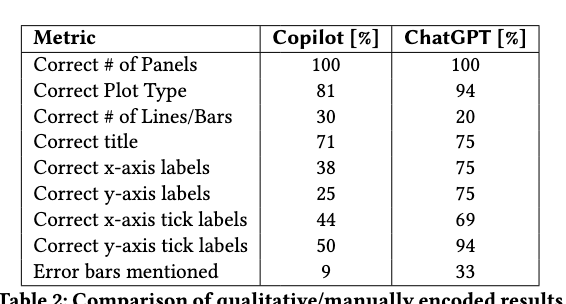

In [220]:
df['question'].unique()

array(['How many panels are in this figure?',
       'What is the plot style used in this figure?',
       'What is the colormap that was used in this figure?',
       'What is the aspect ratio of this figure?',
       'What are the titles for each figure panel?',
       'What are the x-axis titles for each figure panel?',
       'What are the values for each of the tick marks on the x-axis?',
       'What are the values for each of the tick marks on the y-axis?',
       'What are the plot types for each panel in the figure?',
       'What are the matplotlib linestyles in this figure panel?',
       'How many lines are there in the specified figure panel?',
       'How many scatter points are there in the specified figure panel?',
       'What is the mean value of the data along the color-axis in this figure panel? ',
       'What is the mean value of the data along the x-axis in this figure panel? ',
       'What is the mean value of the data along the y-axis in this figure panel? ',


In [221]:
dfsub1 = df[(df['question'] == 'How many panels are in this figure?') & (df['model']=='chatgpt')]
dfsub1

,image id,plot number,plot type,question,use list,model,model id,LMM Answer,GT Answer,Level
10122,Picture145,NaN,None,How many panels are in this figure?,False,chatgpt,gpt-5-nano-2025-08-07,"{'nrows': 1, 'ncols': 2}","{'nrows': 1, 'ncols': 2}",Level 1
10150,Picture198,NaN,None,How many panels are in this figure?,False,chatgpt,gpt-5-nano-2025-08-07,"{'nrows': 1, 'ncols': 1}","{'nrows': 1, 'ncols': 1}",Level 1
10167,Picture191,NaN,None,How many panels are in this figure?,False,chatgpt,gpt-5-nano-2025-08-07,"{'nrows': 2, 'ncols': 4}","{'nrows': 2, 'ncols': 4}",Level 1
10199,Picture81,NaN,None,How many panels are in this figure?,False,chatgpt,gpt-5-nano-2025-08-07,"{'nrows': 2, 'ncols': 1}","{'nrows': 1, 'ncols': 1}",Level 1
10221,Picture168,NaN,None,How many panels are in this figure?,False,chatgpt,gpt-5-nano-2025-08-07,"{'nrows': 1, 'ncols': 1}","{'nrows': 1, 'ncols': 1}",Level 1
...,...,...,...,...,...,...,...,...,...,...
15048,Picture51,NaN,None,How many panels are in this figure?,False,chatgpt,gpt-5-nano-2025-08-07,"{'nrows': 1, 'ncols': 1}","{'nrows': 1, 'ncols': 1}",Level 1
15070,Picture101,NaN,None,How many panels are in this figure?,False,chatgpt,gpt-5-nano-2025-08-07,"{'nrows': 1, 'ncols': 1}","{'nrows': 1, 'ncols': 1}",Level 1
15087,Picture187,NaN,None,How many panels are in this figure?,False,chatgpt,gpt-5-nano-2025-08-07,"{'nrows': 1, 'ncols': 5}","{'nrows': 1, 'ncols': 5}",Level 1
15119,Picture175,NaN,None,How many panels are in this figure?,False,chatgpt,gpt-5-nano-2025-08-07,"{'nrows': 4, 'ncols': 5}","{'nrows': 3, 'ncols': 5}",Level 1


In [222]:
gt = []; lmm = []
for i in range(len(dfsub1)):
    d = dfsub1.iloc[i]
    l = d['LMM Answer']
    g = d['GT Answer']
    lmm.append(l['nrows']*l['ncols'])
    gt.append(g['nrows']*g['ncols'])

gt = np.array(gt); lmm = np.array(lmm)

In [223]:
len(gt), len(lmm)

(200, 200)

In [224]:
#gt-lmm

In [225]:
#lmm

In [ ]:
# assume order is relatively correct -- associate closest to gt
from Levenshtein import distance as levenshtein_distance # Assuming you have python-Levenshtein installed

# sweet little algo to do associations
def map_lg_gt(l,g, verbose=True):
    g_index = 0
    l_gt_map_index = []
    for ll in l:
        darr = []
        for gg in g:
            darr.append(levenshtein_distance(gg, ll))
        darr = np.array(darr)[g_index:]
        if len(darr) == 0:
            import sys; sys.exit()
        min_ind = np.argmin(darr) + g_index
        l_gt_map_index.append(min_ind)
        #print('min_ind, g_index', min_ind, g_index)
        g_index = min_ind

    # see if any double counted
    skipMap = False; warning = False
    if len(np.unique(l_gt_map_index)) != len(l_gt_map_index):
        if len(np.unique(l_gt_map_index)) == 1: # just one option
            skipMap = True
            l_mapped = deepcopy(l)
            l_mapped = np.array(l_mapped).tolist()
            while len(l_mapped) < len(g):
                l_mapped.append('')
            l_mapped = np.array(l_mapped)
        else:
            warning = True
            if verbose: print('[WARNING]: dont have solution for non uniques! (gt)')
            #import sys; sys.exit()

    if not skipMap:
        l_mapped = []
        for i in range(len(g)):
            if i in l_gt_map_index:
                l_mapped.append(l[l_gt_map_index.index(i)])
            else:
                l_mapped.append('')

    g_mapped = deepcopy(g)

    if warning and verbose:
        for gm,lm in zip(g_mapped,l_mapped):
            if gm == '': gm = '<EMPTY>'
            if lm == '': lm = '<EMPTY>'
            print(gm, '||', lm)
        print('')

    return l_mapped, g_mapped


def map_lg_lt(l_save, g_save, verbose=True):
    # swap and loop
    g = deepcopy(l_save)
    l = deepcopy(g_save)

    g_index = 0
    l_gt_map_index = []
    g_nospace = []
    maxl = -1
    for ill,ll in enumerate(l):
        if ll.replace(' ', '') == '':
            continue
        darr = []
        g_nospace.append(ll)
        if len(ll) > maxl: maxl = len(ll)
        for gg in g:
            darr.append(levenshtein_distance(gg, ll))

        darr = np.array(darr)[g_index:]
        if len(darr) == 0:
            import sys; sys.exit()
        min_ind = np.argmin(darr) + g_index
        l_gt_map_index.append(min_ind)
        #print('min_ind, g_index', min_ind, g_index)
        g_index = min_ind

    skipMap = False; warning = False
    if len(np.unique(l_gt_map_index)) != len(l_gt_map_index):
        if len(np.unique(l_gt_map_index)) == 1: # just one option
            skipMap = True
            g_mapped = deepcopy(g_save)
            g_mapped = np.array(g_mapped).tolist()
            while len(g_mapped) < len(l_save):
                g_mapped.append('')
            g_mapped = np.array(g_mapped)
        else:
            warning = True
            if verbose: print('[WARNING]: dont have solution for non uniques! (lt)')
            #import sys; sys.exit()

    if not skipMap:
    # loop and fill g
        g_mapped = np.repeat('', len(l_save)).astype('<U'+str(maxl+1))
        for i in range(len(l_save)):
            if i in l_gt_map_index:
                g_mapped[i] = g_nospace[l_gt_map_index.index(i)]

    l_mapped = deepcopy(l_save)

    if warning and verbose:
        for gm,lm in zip(g_mapped,l_mapped):
            if gm == '': gm = '<EMPTY>'
            if lm == '': lm = '<EMPTY>'
            print(gm, '||', lm)
        print('')

    return l_mapped, g_mapped

In [492]:
def calc_iqr(diff1):
    diff1 = np.array(diff1)
    diff1 = diff1[~np.isnan(diff1)]
    q1 = np.percentile(diff1, 25)
    q3 = np.percentile(diff1, 75)
    iqr = q3 - q1
    return iqr

def count_nan(lmm):
    lmm = np.array(lmm)
    calc_nan = np.array(lmm)
    try:
        calc_nan = len(calc_nan[np.isnan(calc_nan)])    
    except:
        calc_nan = len(calc_nan[calc_nan == None])
    return calc_nan


def get_lmm_gt(dfsub2, type, verbose=True):
    if type == 'binary string':
        gt = []; lmm = []
        for v in dfsub2['GT Answer'].values:
            gt.append(list(v.values())[0].lower())
        gt = np.array(gt)
        for v in dfsub2['LMM Answer'].values:
            lmm.append(list(v.values())[0].lower())
        lmm = np.array(lmm)
    elif type == 'float' or type == 'float per panel':
        gt = []; lmm = []
        for v in dfsub2['GT Answer'].values:
            gt.append(list(v.values())[0])
        gt = np.array(gt)
        for v in dfsub2['LMM Answer'].values: # v = {'mean': 5.0}
            l = list(v.values())[0]
            if l is None:
                l = np.nan
            lmm.append(l)
        lmm = np.array(lmm)
        gt = np.array(gt)
    elif type == 'string list' or type == 'binary string list':
        gt = []; lmm = []
        # have to do at same time to match lists
        for vgt,vlmm in zip(dfsub2['GT Answer'].values, dfsub2['LMM Answer'].values):
            k = list(vgt.keys())[0]
            g = vgt[k]
            l = vlmm[k]
            try:
                # same lenghts?
                if len(g) > len(l):
                    lmapped,gmapped = map_lg_gt(deepcopy(l),deepcopy(g), verbose=verbose)
                elif len(g) < len(l):
                    lmapped,gmapped = map_lg_lt(deepcopy(l),deepcopy(g), verbose=verbose)
                elif len(g) == len(l):
                    lmapped = deepcopy(l)
                    gmapped = deepcopy(g)  
            except:
                if np.isnan(l):
                    lmapped = np.repeat('', len(g))
                    gmapped = deepcopy(g)
                else:
                    print('cannot figure this out!')
                    lakdsjl

            for gg,ll in zip(gmapped,lmapped): # lower
                if '<EMPTY>' in gg: 
                    print("!!!!!!!!!!!!!! ERROR ERROR ERROR !!!!!!!!!!!!!")
                    import sys; sys.exit()
                gt.append(gg)
                lmm.append(ll)      

        # print('NO IMPLEMENTATION', type)
        # import sys; sys.exit()

    return gt, lmm

## Figure-Level Questions

In [467]:
# figure-level questions
questions_figure = [
    {'tag':'# panels', 'question':'How many panels are in this figure?', 'type':'special'},
    {'tag':'plot type', 'question':'What is the plot style used in this figure?', 'type':'binary string'},
    {'tag':'colormap', 'question':'What is the colormap that was used in this figure?', 'type':'binary string'},
    {'tag':'aspect ratio', 'question':'What is the aspect ratio of this figure?', 'type':'float'},
    #{'tag':'mean (x)', 'question':'What is the mean value of the data along the x-axis in this figure panel? ', 'type':'float per panel'}
]

# dftable = {'question':[]}
# for m in df['model'].unique():
#     dftable

# fill level and level types
for q in questions_figure:
    dfsub = df[df['question']==q['question']]
    l = dfsub['Level'].unique()
    if len(l) > 1:
        print('issue with unique level')
        import sys; sys.exit()
    q['Level'] = l[0]
    lt = dfsub['Level Type'].unique()
    if len(lt) > 1:
        print('issue with unique level type')
        import sys; sys.exit()
    q['Level Type'] = lt[0]    


for q in questions_figure:
    dfsub = df[df['question']==q['question']]
    models = {}
    for model in dfsub['model'].unique():
        dfsub2 = dfsub[dfsub['model']==model]
        if q['tag'] == '# panels': # something special
            gt = []
            for g in dfsub2['GT Answer'].values:
                gt.append(g['nrows']*g['ncols'])
            lmm = []
            for l in dfsub2['LMM Answer'].values:
                lmm.append(l['nrows']*l['ncols'])
            calc = np.abs(np.array(gt)-np.array(lmm))
            models[model] = {'mean diff': np.mean(calc), 'median diff':np.median(calc),
                             'std diff':np.std(calc), 'iqr diff':calc_iqr(calc), 
                             'median gt':np.median(gt), 'mean gt':np.mean(gt), 
                             'number nans':count_nan(lmm)}
            #import sys; sys.exit()
        elif q['type'] == 'binary string':
            gt, lmm = get_lmm_gt(dfsub2, q['type'])
            calc = []
            for g,l in zip(gt,lmm):
                if g == l:
                    calc.append(1)
                else:
                    calc.append(0)
            models[model] = {'mean diff': np.mean(calc), 'median diff':np.median(calc),
                             'std diff':np.std(calc), 'iqr diff':calc_iqr(calc), 
                             'number nans':count_nan(lmm)}
            #import sys; sys.exit()
        elif q['type'] == 'float': # single float number
            gt, lmm = get_lmm_gt(dfsub2, q['type'])
            calc =  np.abs(np.array(gt)-np.array(lmm)) 
            models[model] = {'mean diff': np.nanmean(calc), 'median diff':np.nanmedian(calc),
                             'std diff':np.nanstd(calc), 'iqr diff':calc_iqr(calc), 
                             'median gt':np.nanmedian(gt), 'mean gt':np.nanmean(gt), 
                             'number nans':count_nan(lmm)}   
        else:
            print(q['tag'])
            import sys; sys.exit()
    q['answers'] = deepcopy(models)

In [259]:
#np.mean(calc/gt)

In [271]:
#questions_figure

In [283]:
# into dataframe
round_val = 2
divider = None #'gt'
average = 'mean'

#df_figure = {'tag':[], 'question':[]} #, '# nans':[]}
df_figure = {'tag':[]} #, '# nans':[]}

df_question_tags = {'tag':[], 'question':[], 'Level':[], 'Type':[]} # for longer list of questions in a table later

mean_gts = {}

# fill models
for dn in dirnames:
    if divider is not None:
        dnr = dn.replace('_', '\\_') + ' ('+average+' diff)/('+average+' gt)'
    else:
        dnr = dn.replace('_', '\\_') + ' ' + average + ' diff'
    df_figure[dnr] = []
    #mean_gts[dnr] = ''
for dn in dirnames:
    df_figure[dn.replace('_', '\\_') + ' \\# nans'] = []

if average == 'median':
    spread = 'iqr'
else:
    spread = 'std'

adder_binary = '$^\\dagger$'
column_format = '|'
column_c = True
column_format_tag = '|'
for qa in questions_figure:
    df_figure['tag'].append(qa['tag'].replace('#', '\\#'))
    if column_c: 
        column_format += 'l|'
        column_format_tag += 'l|'
    # question one
    df_question_tags['tag'].append(qa['tag'].replace('#', '\\#'))
    df_question_tags['question'].append(qa['question'].replace('#', '\\#'))
    df_question_tags['Level'].append(qa['Level'].replace('Level',''))
    df_question_tags['Type'].append(qa['Level Type'].replace('-level questions',''))
    if column_c: column_format_tag += 'l|l|l|'
    # loop models
    for model, q in qa['answers'].items():
        adder = ''
        if column_c: column_format += 'c|c|'
        if qa['type'] == 'special' or qa['type'] == 'float':
            sm = q[average + ' diff']
            if divider is not None:
                sm = sm*q[average + ' gt']*100
            sd = q[spread + ' diff'] 
            if divider is not None:
                sd = sd*q[average + ' gt']*100
            mean_gts[average + ' ' + qa['tag'].replace('#', '\\#')] = q[average + ' gt']
        elif qa['type'] == 'binary string':
            sm = q[average + ' diff'] 
            if divider is not None:
                sm *= 100
            sd = q[spread + ' diff'] 
            if divider is not None:
                sd *= 100 
            adder = adder_binary
        else:
            print('no idea!')
            import sys; sys.exit()   

        if divider is not None:
            dnr = model.replace('_', '\\_') + ' ('+average+' diff)/('+average+' gt)'
        else:
            dnr = model.replace('_', '\\_') + ' ' + average  + ' diff'
        df_figure[dnr].append('$' + str(round(sm,round_val)) + ' \\pm ' + str(round(sd,round_val)) + '$' + adder)
        df_figure[model.replace('_', '\\_') + ' \\# nans'].append(q['number nans']) 
    column_c = False

df_figure = pd.DataFrame(df_figure)
df_question_tags = pd.DataFrame(df_question_tags)

In [284]:
df_figure

,tag,claude mean diff,gemini\_1.5 mean diff,chatgpt mean diff,claude \# nans,gemini\_1.5 \# nans,chatgpt \# nans
0,\# panels,$0.16 \pm 0.73$,$6.3 \pm 22.17$,$2.19 \pm 9.81$,0,0,0
1,plot type,$0.04 \pm 0.21$$^\dagger$,$0.06 \pm 0.24$$^\dagger$,$0.12 \pm 0.32$$^\dagger$,0,0,0
2,colormap,$0.16 \pm 0.37$$^\dagger$,$0.34 \pm 0.47$$^\dagger$,$0.22 \pm 0.42$$^\dagger$,0,0,0
3,aspect ratio,$1.07 \pm 0.96$,$1.07 \pm 1.72$,$1.16 \pm 1.23$,0,9,1


In [285]:
mean_gts

{'mean \\# panels': 4.75, 'mean aspect ratio': 0.9649194486515265}

In [ ]:
from utils.latex_utils import table_iConf_format

```latex
\begin{table}[h!]
\begin{tabular}{|l|c|}
\hline
\rowcolor{black}
\color{white} Catalyst & \color{white} Instances \\
\hline
Specific person, family, names & 75 \\ \hline
...
Received data from other researcher or family & 6 \\ \hline
\end{tabular}
\centering
\caption*{\textbf{Table 1.} This text should be normal and not bold.}
\end{table}
```

In [288]:
label='tab:figure_level'
caption = 'Figure - level questions.  The $\\dagger$ references the means of binary string comparisons. '
caption += 'The ' 
if len(list(mean_gts.keys())) == 2:
    for k,v in mean_gts.items():
        caption += k + ' is ' + str(round(v,2)) + ' and the '
    caption = caption.removesuffix(' and the ') + '.'

latex_table = table_iConf_format(df_figure, label, caption, column_format)

print(latex_table)

\begin{table}[h!]
\begin{tabular}{|l|c|c|c|c|c|c|}
\hline
\rowcolor{black}
\color{white} tag & \color{white} claude mean diff & \color{white} gemini\_1.5 mean diff & \color{white} chatgpt mean diff & \color{white} claude \# nans & \color{white} gemini\_1.5 \# nans & \color{white} chatgpt \# nans \\ 
\hline
\# panels & $0.16 \pm 0.73$ & $6.3 \pm 22.17$ & $2.19 \pm 9.81$ & 0 & 0 & 0 \\ \hline
plot type & $0.04 \pm 0.21$$^\dagger$ & $0.06 \pm 0.24$$^\dagger$ & $0.12 \pm 0.32$$^\dagger$ & 0 & 0 & 0 \\ \hline
colormap & $0.16 \pm 0.37$$^\dagger$ & $0.34 \pm 0.47$$^\dagger$ & $0.22 \pm 0.42$$^\dagger$ & 0 & 0 & 0 \\ \hline
aspect ratio & $1.07 \pm 0.96$ & $1.07 \pm 1.72$ & $1.16 \pm 1.23$ & 0 & 9 & 1 \\ \hline
\end{tabular}
\centering
\caption{Figure - level questions.  The $\dagger$ references the means of binary string comparisons. The mean \# panels is 4.75 and the mean aspect ratio is 0.96.}
\label{tab:figure_level}
\end{table}



## Plot-level questions

In [289]:
df.head()

,image id,plot number,plot type,question,use list,model,model id,LMM Answer,GT Answer,Level,Level Type
0,Picture145,NaN,None,How many panels are in this figure?,False,claude,claude-sonnet-4-20250514,"{'nrows': 1, 'ncols': 2}","{'nrows': 1, 'ncols': 2}",Level 1,Figure-level questions
1,Picture145,NaN,None,What is the plot style used in this figure?,False,claude,claude-sonnet-4-20250514,{'plot style': 'ggplot'},{'plot style': 'Solarize_Light2'},Level 1,Figure-level questions
2,Picture145,NaN,None,What is the colormap that was used in this fig...,False,claude,claude-sonnet-4-20250514,{'colormap': 'viridis'},{'colormap': 'gray'},Level 1,Figure-level questions
3,Picture145,NaN,None,What is the aspect ratio of this figure?,False,claude,claude-sonnet-4-20250514,{'aspect ratio': 1.0},{'aspect ratio': 0.4521328929757427},Level 1,Figure-level questions
4,Picture145,NaN,None,What are the titles for each figure panel?,False,claude,claude-sonnet-4-20250514,"{'title': ['', '']}","{'title': ['', '']}",Level 1,Figure-level questions


### Level 1

In [251]:
df[(df['Level Type']=='Figure-level questions') & (df['Level'] == 'Level 1')]['question'].unique()

array(['How many panels are in this figure?',
       'What is the plot style used in this figure?',
       'What is the colormap that was used in this figure?',
       'What is the aspect ratio of this figure?',
       'What are the titles for each figure panel?',
       'What are the x-axis titles for each figure panel?',
       'What are the values for each of the tick marks on the x-axis?',
       'What are the values for each of the tick marks on the y-axis?',
       'What are the plot types for each panel in the figure?'],
      dtype=object)

In [249]:
# Level 1
df[(df['Level Type']=='Plot-level questions') & (df['Level'] == 'Level 1')]['question'].unique()

array(['What are the matplotlib linestyles in this figure panel?',
       'How many lines are there in the specified figure panel?',
       'How many scatter points are there in the specified figure panel?',
       'How many bars are there in the specified figure panel?'],
      dtype=object)

```python
questions_figure = [
    {'tag':'# panels', 'question':'How many panels are in this figure?', 'type':'special'},
    {'tag':'plot type', 'question':'What is the plot style used in this figure?', 'type':'binary string'},
    {'tag':'colormap', 'question':'What is the colormap that was used in this figure?', 'type':'binary string'},
    {'tag':'aspect ratio', 'question':'What is the aspect ratio of this figure?', 'type':'float'},
]
```

In [497]:
# JPN note: x-axis is wrong, ignore this question
questions_L1 = [
       {'tag':'titles', 'question': 'What are the titles for each figure panel?', 'type':'string list'},
       {'tag':'linestyles', 'question':'What are the matplotlib linestyles in this figure panel?', 'type':'binary string list'},
       {'tag':'# lines', 'question':'How many lines are there in the specified figure panel?', 'type':'float'},
       {'tag':'# scatters', 'question':'How many scatter points are there in the specified figure panel?', 'type':'float'},
       {'tag':'# bars', 'question':'How many bars are there in the specified figure panel?', 'type':'float'},
]



# fill level and level types
for q in questions_L1:
    dfsub = df[df['question']==q['question']]
    l = dfsub['Level'].unique()
    if len(l) > 1:
        print('issue with unique level')
        import sys; sys.exit()
    q['Level'] = l[0]
    lt = dfsub['Level Type'].unique()
    if len(lt) > 1:
        print('issue with unique level type')
        import sys; sys.exit()
    q['Level Type'] = lt[0]    


for q in questions_L1:
    dfsub = df[df['question']==q['question']]
    models = {}
    for model in dfsub['model'].unique():
        dfsub2 = dfsub[dfsub['model']==model]
        if q['tag'] == '# panels': # something special
            gt = []
            for g in dfsub2['GT Answer'].values:
                gt.append(g['nrows']*g['ncols'])
            lmm = []
            for l in dfsub2['LMM Answer'].values:
                lmm.append(l['nrows']*l['ncols'])
            calc = np.abs(np.array(gt)-np.array(lmm))
            models[model] = {'mean diff': np.mean(calc), 'median diff':np.median(calc),
                             'std diff':np.std(calc), 'iqr diff':calc_iqr(calc), 
                             'median gt':np.median(gt), 'mean gt':np.mean(gt), 
                             'number nans':count_nan(lmm)}
            #import sys; sys.exit()
        elif q['type'] == 'binary string': # or q['type'] == 'binary string list':
            gt, lmm = get_lmm_gt(dfsub2, q['type'])
            calc = []
            for g,l in zip(gt,lmm):
                if g == l:
                    calc.append(1)
                else:
                    calc.append(0)
            models[model] = {'mean diff': np.mean(calc), 'median diff':np.median(calc),
                             'std diff':np.std(calc), 'iqr diff':calc_iqr(calc), 
                             'number nans':count_nan(lmm)}
            #import sys; sys.exit()
        elif q['type'] == 'float': # single float number
            gt, lmm = get_lmm_gt(dfsub2, q['type'])
            calc =  np.abs(np.array(gt)-np.array(lmm)) 
            models[model] = {'mean diff': np.nanmean(calc), 'median diff':np.nanmedian(calc),
                             'std diff':np.nanstd(calc), 'iqr diff':calc_iqr(calc), 
                             'median gt':np.nanmedian(gt), 'mean gt':np.nanmean(gt), 
                             'number nans':count_nan(lmm)}   
        elif q['type'] == 'string list':
            # loop over every figure
            calc = [] # normalized distance
            lmm_tot = []
            for iq in range(len(dfsub2)):
                dfsub22 = dfsub2.iloc[iq]
                gt, lmm = get_lmm_gt(dfsub22.to_frame().T, q['type'], verbose=False)
                lmm_tot.extend(lmm)
                # get distance/length
                total_d = 0; total_l = 0
                for g, l in zip(gt,lmm):
                    d = levenshtein_distance(g,l)
                    total_d += d
                    if len(g) > 0:
                        total_l += len(g)
                    else:
                        total_l += len(l)
                if total_l > 0:
                    calc.append(total_d*1.0/total_l)
                else:
                    calc.append(0)
            # sort of like binar string
            models[model] = {'mean diff': np.mean(calc), 'median diff':np.median(calc),
                             'std diff':np.std(calc), 'iqr diff':calc_iqr(calc), 
                             'number nans':count_nan(lmm_tot)}


                #print('gt:', vgt)
                #print('vlmm:', vlmm)

            #import sys; sys.exit()

        elif q['type'] == 'binary string list':
            # loop over every panel
            calc = [] # normalized distance
            lmm_tot = []
            for iq in range(len(dfsub2)):
                dfsub22 = dfsub2.iloc[iq]
                gt, lmm = get_lmm_gt(dfsub22.to_frame().T, q['type'], verbose=False)
                lmm_tot.extend(lmm)
                for g,l in zip(gt,lmm):
                    if g == l:
                        calc.append(1)
                    else:
                        calc.append(0)
            models[model] = {'mean diff': np.mean(calc), 'median diff':np.median(calc),
                             'std diff':np.std(calc), 'iqr diff':calc_iqr(calc), 
                             'number nans':count_nan(lmm_tot)}

            #import sys; sys.exit()

        else:
            print(q['tag'], q['type'])
            import sys; sys.exit()
    q['answers'] = deepcopy(models)

In [495]:
gt, lmm

(['-', '-', '-', '-', '-'], ['-', '', '', '', ''])

In [496]:
dfsub22.to_frame().T

,image id,plot number,plot type,question,use list,model,model id,LMM Answer,GT Answer,Level,Level Type
5040,Picture32,3.0,line,What are the matplotlib linestyles in this fig...,False,claude,claude-sonnet-4-20250514,{'line styles': ['-']},"{'line styles': ['-', '-', '-', '-', '-']}",Level 1,Plot-level questions


In [431]:
l_save = deepcopy(l)
g_save = deepcopy(g)

In [440]:
if True:

    # swap and loop
    g = deepcopy(l_save)
    l = deepcopy(g_save)

    g_index = 0
    l_gt_map_index = []
    g_nospace = []
    maxl = -1
    for ill,ll in enumerate(l):
        if ll.replace(' ', '') == '':
            continue
        darr = []
        g_nospace.append(ll)
        if len(ll) > maxl: maxl = len(ll)
        for gg in g: 
            #if gg.replace(' ', '') == '': # GT is empty string
            darr.append(levenshtein_distance(gg, ll))

        darr = np.array(darr)[g_index:]
        if len(darr) == 0:
            import sys; sys.exit()
        min_ind = np.argmin(darr) + g_index
        l_gt_map_index.append(min_ind)
        #print('min_ind, g_index', min_ind, g_index)
        g_index = min_ind

    # see if any double counted
    skipMap = False
    if len(np.unique(l_gt_map_index)) != len(l_gt_map_index):
        if len(np.unique(l_gt_map_index)) == 1: # just one option
            skipMap = True
            g_mapped = deepcopy(g_save)
            g_mapped = np.array(g_mapped).tolist()
            while len(g_mapped) < len(l_save):
                g_mapped.append('')
            g_mapped = np.array(g_mapped)
        else:
            print('dont have solution for non uniques! (lt)')
            import sys; sys.exit()

    if not skipMap:
    # loop and fill g
        g_mapped = np.repeat('', len(l_save)).astype('<U'+str(maxl+1))
        for i in range(len(l_save)):
            if i in l_gt_map_index:
                g_mapped[i] = g_nospace[l_gt_map_index.index(i)]

    l_mapped = deepcopy(l_save)

In [439]:
l_gt_map_index

[0, 0, 0]

In [441]:
g_mapped

array(['PROCEDURE CENTRES ORIGIN ELEMENT', '', 'Moves',
       'OCCUPATION STABILITY EVOLVES RATIOS UNITY', '', ''], dtype='<U41')

In [436]:
len(l_save), len(g_save)

(6, 5)

In [432]:
# for g2,l2 in zip(g_mapped, l_mapped):
#     print(g2, '||', l2)
#     print('')

In [422]:
l_mapped

['Collision $\\gamma = 6.6$',
 'State Extension $\\mathcal{V}$',
 'READING LEVEL PROBLEMS ICE INSTABILITY',
 'Stochastic Fractal',
 '$2\\pi P_{orb} = 2.2 \\times 10^{-6}$ HEIGHT',
 'HALO Spread Resolutions Polar',
 '$\\sim 1/3$ SCOPE $P_T > P_L$',
 'Years',
 'PSPC EDGES ENTIRE',
 'FARADAY ACS CONSERVATION',
 'BIASES OCCUPATION ARC EXHIBIT',
 '$z_{obs} = -1.7$',
 'Averages Lists Matter',
 '',
 'Cell',
 '$\\pm 10^4 F(\\sigma) = N_{pl}^2 + \\zeta$',
 'Velocity']

In [401]:
g_mapped

[]

In [383]:
l_gt_map_index

[1, 2, 7, 10, 12]

In [388]:
g_mapped

['',
 '',
 'State Extension Discs Display',
 '',
 '',
 '',
 '',
 'VARIANCE LEVEL PROBLEMS ICE INSTABILITY',
 '',
 '',
 'Fractal',
 '',
 '',
 '',
 '',
 '',
 '']

In [376]:
g_save

['',
 'State Extension Discs Display',
 'VARIANCE LEVEL PROBLEMS ICE INSTABILITY',
 'Fractal',
 '',
 'BIASES OCCUPATION ARC EXHIBIT',
 '',
 'Averages Lists Matter']

In [377]:
l_save

['Collision $\\gamma = 6.6$',
 'State Extension $\\mathcal{V}$',
 'READING LEVEL PROBLEMS ICE INSTABILITY',
 'Stochastic Fractal',
 '$2\\pi P_{orb} = 2.2 \\times 10^{-6}$ HEIGHT',
 'HALO Spread Resolutions Polar',
 '$\\sim 1/3$ SCOPE $P_T > P_L$',
 'Years',
 'PSPC EDGES ENTIRE',
 'FARADAY ACS CONSERVATION',
 'BIASES OCCUPATION ARC EXHIBIT',
 '$z_{obs} = -1.7$',
 'Averages Lists Matter',
 '',
 'Cell',
 '$\\pm 10^4 F(\\sigma) = N_{pl}^2 + \\zeta$',
 'Velocity']

In [353]:
# assume order is relatively correct -- associate closest to gt
from Levenshtein import distance as levenshtein_distance # Assuming you have python-Levenshtein installed

# sweet little algo to do associations
if len(l) > len(g):
    print('dont have solution for l > g!!')
    import sys; sys.exit()
g_index = 0
l_gt_map_index = []
for ll in l:
    darr = []
    for gg in g:
        darr.append(levenshtein_distance(gg, ll))

    darr = np.array(darr)[g_index:]
    if len(darr) == 0:
        import sys; sys.exit()
    min_ind = np.argmin(darr) + g_index
    l_gt_map_index.append(min_ind)
    #print('min_ind, g_index', min_ind, g_index)
    g_index = min_ind

# see if any double counted
if len(np.unique(l_gt_map_index)) != len(l_gt_map_index):
    print('dont have solution for non uniques!')
    import sys; sys.exit()

l_mapped = []
for i in range(len(g)):
    if i in l_gt_map_index:
        l_mapped.append(l[l_gt_map_index.index(i)])
    else:
        l_mapped.append('')

In [354]:
l_mapped

['',
 'HELP STRIP STEP $F\\sim n_{H}u_s$',
 '',
 'Tube',
 'Distances Turbulence Dip Spectrum',
 '',
 'Colour Contribution $B(z)$ $-2.31$ Holes',
 '']

In [355]:
g

['',
 'HELP STRIP STEP $F \\sim n_{H}u$ ',
 '',
 'Tube',
 'Torus Distances Turbulence Dip Spectrum',
 'Jets',
 'Colour Contribution',
 'Warp $B(z)$  $-2.31$  Holes Sum']

In [352]:
l

['HELP STRIP STEP $F\\sim n_{H}u_s$',
 'Tube',
 'Distances Turbulence Dip Spectrum',
 'Colour Contribution $B(z)$ $-2.31$ Holes']

In [344]:
g

['',
 'HELP STRIP STEP $F \\sim n_{H}u$ ',
 '',
 'Tube',
 'Torus Distances Turbulence Dip Spectrum',
 'Jets',
 'Colour Contribution',
 'Warp $B(z)$  $-2.31$  Holes Sum']

In [327]:
import numpy as np
from dtw import dtw
from sklearn.preprocessing import LabelEncoder
from Levenshtein import distance as levenshtein_distance # Assuming you have python-Levenshtein installed

array1 = deepcopy(g)
array2 = deepcopy(l)

# Define a custom distance function for individual strings
def string_cost_function(s1, s2):
    return levenshtein_distance(s1, s2)

nanchar = None

# Calculate the DTW distance and optimal path
#alignment = dtw(array1_encoded, array2_encoded, keep_internals=True)
alignment = dtw(array1, array2, keep_internals=True, dist_method=string_cost_function)

In [332]:
print(array1)
print(array2)

['', 'HELP STRIP STEP $F \\sim n_{H}u$ ', '', 'Tube', 'Torus Distances Turbulence Dip Spectrum', 'Jets', 'Colour Contribution', 'Warp $B(z)$  $-2.31$  Holes Sum']
['HELP STRIP STEP $F\\sim n_{H}u_s$', 'Tube', 'Distances Turbulence Dip Spectrum', 'Colour Contribution $B(z)$ $-2.31$ Holes']


In [329]:
print(f"DTW path indices1: {alignment.index1}")
print(f"DTW path indices2: {alignment.index2}")

DTW path indices1: [0 1 2 3 4 5 6 7]
DTW path indices2: [0 0 0 1 1 1 2 3]


In [ ]:
# Create aligned arrays with None for repeated/added entries
def create_aligned_arrays_with_none(arr1, arr2, index1, index2):
    aligned1 = []
    aligned2 = []
    
    prev_idx1 = -1
    prev_idx2 = -1
    
    for i1, i2 in zip(index1, index2):
        # For array1: if index repeats, use None, otherwise use the value
        if i1 == prev_idx1:
            aligned1.append(nanchar)
        else:
            aligned1.append(arr1[i1])
        
        # For array2: if index repeats, use None, otherwise use the value
        if i2 == prev_idx2:
            aligned2.append(nanchar)
        else:
            aligned2.append(arr2[i2])
        
        prev_idx1 = i1
        prev_idx2 = i2
    
    return np.array(aligned1, dtype=object), np.array(aligned2, dtype=object)

# Get aligned arrays with None for repeated entries (using original string arrays)
aligned_array1_none, aligned_array2_none = create_aligned_arrays_with_none(
    array1, array2, alignment.index1, alignment.index2
)

print(f"DTW Distance: {alignment.distance}")
print(f"Warping Path: {alignment.path}")
print(f"Original array1: {array1}")
print(f"Original array2: {array2}")
print(f"DTW path indices1: {alignment.index1}")
print(f"DTW path indices2: {alignment.index2}")
print(f"Aligned array1 (None for repeats): {aligned_array1_none}")
print(f"Aligned array2 (None for repeats): {aligned_array2_none}")

In [326]:
import numpy as np
from dtw import dtw
from sklearn.preprocessing import LabelEncoder
from Levenshtein import distance as levenshtein_distance # Assuming you have python-Levenshtein installed


# # Create two arrays representing time series with different lengths
# array1 = np.array([3, 4, 5, 4, 5], dtype=float)  # Use float to allow NaN
# array2 = np.array([2, 3, 4, 5, 4, 5, 6], dtype=float)
#array1 = np.array(deepcopy(g), dtype='object')
#array2 = np.array(deepcopy(l), dtype='object')
array1 = deepcopy(g)
array2 = deepcopy(l)

# Define a custom distance function for individual strings
def string_cost_function(s1, s2):
    return levenshtein_distance(s1, s2)

# label_encoder = LabelEncoder()
# all_strings = np.concatenate([array1, array2])
# #label_encoder.fit(all_strings)
# label_encoder.fit(np.unique(all_strings))

# array1_encoded = label_encoder.transform(array1)
# array2_encoded = label_encoder.transform(array2)

nanchar = None

# Calculate the DTW distance and optimal path
#alignment = dtw(array1_encoded, array2_encoded, keep_internals=True)
alignment = dtw(array1, array2, keep_internals=True, dist_method=string_cost_function)


# Create aligned arrays with None for repeated/added entries
def create_aligned_arrays_with_none(arr1, arr2, index1, index2):
    aligned1 = []
    aligned2 = []
    
    prev_idx1 = -1
    prev_idx2 = -1
    
    for i1, i2 in zip(index1, index2):
        # For array1: if index repeats, use None, otherwise use the value
        if i1 == prev_idx1:
            aligned1.append(nanchar)
        else:
            aligned1.append(arr1[i1])
        
        # For array2: if index repeats, use None, otherwise use the value
        if i2 == prev_idx2:
            aligned2.append(nanchar)
        else:
            aligned2.append(arr2[i2])
        
        prev_idx1 = i1
        prev_idx2 = i2
    
    return np.array(aligned1, dtype=object), np.array(aligned2, dtype=object)

# Get aligned arrays with None for repeated entries (using original string arrays)
aligned_array1_none, aligned_array2_none = create_aligned_arrays_with_none(
    array1, array2, alignment.index1, alignment.index2
)

print(f"DTW Distance: {alignment.distance}")
print(f"Warping Path: {alignment.path}")
print(f"Original array1: {array1}")
print(f"Original array2: {array2}")
print(f"DTW path indices1: {alignment.index1}")
print(f"DTW path indices2: {alignment.index2}")
print(f"Aligned array1 (None for repeats): {aligned_array1_none}")
print(f"Aligned array2 (None for repeats): {aligned_array2_none}")



# # Create aligned arrays with NaN for repeated/added entries
# def create_aligned_arrays_with_nan(arr1, arr2, index1, index2):
#     aligned1 = []
#     aligned2 = []
    
#     prev_idx1 = -1
#     prev_idx2 = -1
    
#     for i1, i2 in zip(index1, index2):
#         # For array1: if index repeats, use NaN, otherwise use the value
#         if i1 == prev_idx1:
#             aligned1.append(nanchar)
#         else:
#             aligned1.append(arr1[i1])
        
#         # For array2: if index repeats, use NaN, otherwise use the value
#         if i2 == prev_idx2:
#             aligned2.append(nanchar)
#         else:
#             aligned2.append(arr2[i2])
        
#         prev_idx1 = i1
#         prev_idx2 = i2
    
#     return np.array(aligned1), np.array(aligned2)

# # Get aligned arrays with NaN for repeated entries
# aligned_array1_nan, aligned_array2_nan = create_aligned_arrays_with_nan(
#     array1, array2, alignment.index1, alignment.index2
# )

# print(f"Original array1: {array1}")
# print(f"Original array2: {array2}")
# print(f"DTW path indices1: {alignment.index1}")
# print(f"DTW path indices2: {alignment.index2}")
# print(f"Aligned array1 (NaN for repeats): {aligned_array1_nan}")
# print(f"Aligned array2 (NaN for repeats): {aligned_array2_nan}")

DTW Distance: 9.0


AttributeError: 'DTW' object has no attribute 'path'

In [313]:
aligned_array1_none

array(['', 'HELP STRIP STEP $F \\sim n_{H}u$ ', '', 'Tube',
       'Torus Distances Turbulence Dip Spectrum', 'Jets', None,
       'Colour Contribution', 'Warp $B(z)$  $-2.31$  Holes Sum'],
      dtype=object)

In [314]:
aligned_array2_none

array(['HELP STRIP STEP $F\\sim n_{H}u_s$', None, None, 'Tube', None,
       None, 'Distances Turbulence Dip Spectrum',
       'Colour Contribution $B(z)$ $-2.31$ Holes', None], dtype=object)

In [320]:
array1_encoded

array([0, 4, 0, 8, 7, 6, 1, 9])

In [321]:
array2_encoded

array([5, 8, 3, 2])

In [318]:
np.unique(all_strings)

array(['', 'Colour Contribution',
       'Colour Contribution $B(z)$ $-2.31$ Holes',
       'Distances Turbulence Dip Spectrum',
       'HELP STRIP STEP $F \\sim n_{H}u$ ',
       'HELP STRIP STEP $F\\sim n_{H}u_s$', 'Jets',
       'Torus Distances Turbulence Dip Spectrum', 'Tube',
       'Warp $B(z)$  $-2.31$  Holes Sum'], dtype='<U40')

In [322]:
label_encoder = LabelEncoder()
all_strings = np.concatenate([array1, array2])
#label_encoder.fit(all_strings)
label_encoder.fit(np.unique(all_strings))

array1_encoded = label_encoder.transform(array1)
array2_encoded = label_encoder.transform(array2)

In [323]:
array1_encoded, array2_encoded

(array([0, 4, 0, 8, 7, 6, 1, 9]), array([5, 8, 3, 2]))

In [293]:
dfsub2

,image id,plot number,plot type,question,use list,model,model id,LMM Answer,GT Answer,Level,Level Type
4,Picture145,NaN,None,What are the titles for each figure panel?,False,claude,claude-sonnet-4-20250514,"{'title': ['', '']}","{'title': ['', '']}",Level 1,Figure-level questions
32,Picture198,NaN,None,What are the titles for each figure panel?,False,claude,claude-sonnet-4-20250514,{'title': ['Test']},{'title': ['Test']},Level 1,Figure-level questions
49,Picture191,NaN,None,What are the titles for each figure panel?,False,claude,claude-sonnet-4-20250514,"{'title': ['HELP STRIP STEP $F\sim n_{H}u_s$',...","{'title': ['', 'HELP STRIP STEP $F \sim n_{H}u...",Level 1,Figure-level questions
81,Picture81,NaN,None,What are the titles for each figure panel?,False,claude,claude-sonnet-4-20250514,{'title': ['']},{'title': ['']},Level 1,Figure-level questions
103,Picture168,NaN,None,What are the titles for each figure panel?,False,claude,claude-sonnet-4-20250514,{'title': ['']},{'title': ['']},Level 1,Figure-level questions
...,...,...,...,...,...,...,...,...,...,...,...
4930,Picture51,NaN,None,What are the titles for each figure panel?,False,claude,claude-sonnet-4-20250514,{'title': ['']},{'title': ['']},Level 1,Figure-level questions
4952,Picture101,NaN,None,What are the titles for each figure panel?,False,claude,claude-sonnet-4-20250514,{'title': ['Formation']},{'title': ['Formation']},Level 1,Figure-level questions
4969,Picture187,NaN,None,What are the titles for each figure panel?,False,claude,claude-sonnet-4-20250514,"{'title': ['', '', '', '', '']}","{'title': ['RESOLUTION RETURN', '', 'Loop Rule...",Level 1,Figure-level questions
5001,Picture175,NaN,None,What are the titles for each figure panel?,False,claude,claude-sonnet-4-20250514,"{'title': ['', '', '', '', '', '', '', '', '',...","{'title': ['', '$P_{\rm rot} = 34.6\pm0.8$ Ap...",Level 1,Figure-level questions


In [250]:
# Level 2
df[(df['Level Type']=='Plot-level questions') & (df['Level'] == 'Level 2')]['question'].unique()

array(['What is the mean value of the data along the color-axis in this figure panel? ',
       'What is the mean value of the data along the x-axis in this figure panel? ',
       'What is the mean value of the data along the y-axis in this figure panel? ',
       'What is the median value of the data along the color-axis in this figure panel? ',
       'What is the median value of the data along the x-axis in this figure panel? ',
       'What is the median value of the data along the y-axis in this figure panel? ',
       'Are there error bars on the data along the x-axis in this figure panel?',
       'Are there error bars on the data along the y-axis in this figure panel?',
       'What is the mean value of the data in this figure panel? ',
       'What is the median value of the data in this figure panel? '],
      dtype=object)

In [290]:
# Level 3
df[(df['Level Type']=='Plot-level questions') & (df['Level'] == 'Level 3')]['question'].unique()

array(['What is the underlying distribution used to create the data in this figure panel along the color-axis?',
       'What is the underlying distribution used to create the data in this figure panel in the x/y-plane?',
       'What is the functional relationship between the x and y values in this figure panel?',
       'What is the underlying distribution used to create the data in this figure panel?'],
      dtype=object)

## All Question tags

In [ ]:
label='tab:question_map'
caption = 'Questions and tags.  \\rt{so here I think we wanna list at least all questions but maybe not all tags? only tags if refernced in other tables?}'

latex_table_tag = table_iConf_format(df_question_tags, label, caption, column_format_tag)

print(latex_table_tag)

\begin{table}[h!]
\begin{tabular}{|l|l|l|l|}
\hline
\rowcolor{black}
\color{white} tag & \color{white} question & \color{white} Level & \color{white} Type \\ 
\hline
\# panels & How many panels are in this figure? &  1 & Figure \\ \hline
plot type & What is the plot style used in this figure? &  1 & Figure \\ \hline
colormap & What is the colormap that was used in this figure? &  1 & Figure \\ \hline
aspect ratio & What is the aspect ratio of this figure? &  1 & Figure \\ \hline
\end{tabular}
\centering
\caption{Questions and tags.}
\label{tab:question_map}
\end{table}

